In [1]:
! pip install opencv-contrib-python
! pip install opencv-python
! pip install matplotlib
! pip install numpy
! pip install tensorflow==2.10.1
! pip install keras

In [4]:
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

In [5]:
Datadirectory = r"D:\dataset\train5" #training dataset

In [6]:
Classes = ['angry','fear','happy','neutral','sad','surprise'] #list of classes

D:\dataset\train5\angry


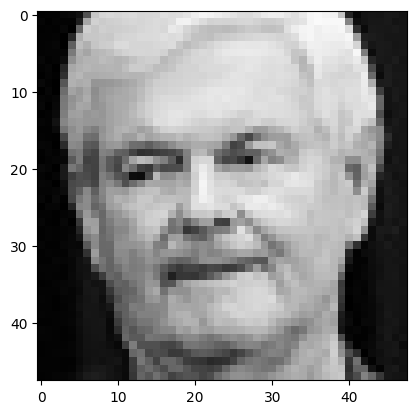

In [7]:
for category in Classes:
  path = os.path.join(Datadirectory,category)
  print(path)
  for img in os.listdir(path):
    img_array=cv2.imread(os.path.join(path,img))
    plt.imshow(cv2.cvtColor(img_array,cv2.COLOR_BGR2RGB))
    plt.show()
    break
  break

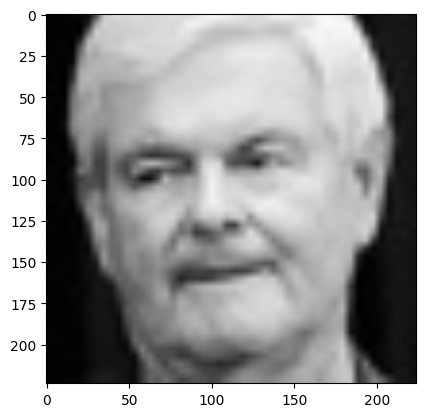

In [8]:
img_size=224
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(cv2.cvtColor(new_array,cv2.COLOR_BGR2RGB))
plt.show()

In [9]:
new_array.shape

(224, 224, 3)

   **read all the image and convert them to array**

In [10]:
training_Data=[] ##data array
def create_training_Data():
  for category in Classes:
    path = os.path.join(Datadirectory,category)
    print(path)
    class_num=Classes.index(category)
    for img in os.listdir(path):
      try:
        img_array=cv2.imread(os.path.join(path,img))
        new_array=cv2.resize(img_array,(img_size,img_size))
        training_Data.append([new_array,class_num])
      except Exception as e:
        pass

In [11]:
create_training_Data()

D:\dataset\train5\angry
D:\dataset\train5\fear
D:\dataset\train5\happy
D:\dataset\train5\neutral
D:\dataset\train5\sad
D:\dataset\train5\surprise


In [12]:
print(len(training_Data))

5424


In [13]:
import random
random.shuffle(training_Data)

In [14]:
x=[] ## data /feature
y=[] ## label

for feature,label in training_Data:
  x.append(feature)
  y.append(label)

x=np.array(x).reshape(-1,img_size,img_size,3)

In [15]:
x.shape

(5424, 224, 224, 3)

In [16]:
x = x/255.0 ##normalize the data

In [17]:
type(y)

list

In [18]:
Y=np.array(y)
Y.shape

(5424,)

In [19]:
X=np.array(x)
X.shape

(5424, 224, 224, 3)

**deep learning model for training**



In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, GlobalAveragePooling2D

In [21]:
model= tf.keras.applications.MobileNetV2() ## pre-train model

In [22]:
base_input = model.layers[0].input
base_output = model.layers[-2].output

In [23]:
base_output

<KerasTensor: shape=(None, 1280) dtype=float32 (created by layer 'global_average_pooling2d')>

In [24]:
final_output = layers.Dense(128)(base_output)
final_output = layers.Activation('relu')(final_output)
final_output = layers.Dense(64)(final_output)
final_output = layers.Activation('relu')(final_output)
final_output = layers.Dense(6,activation='softmax')(final_output)

In [28]:
final_output ##output

<KerasTensor: shape=(None, 6) dtype=float32 (created by layer 'dense_2')>

In [29]:
new_model = keras.Model(inputs = base_input, outputs=final_output)

In [30]:
new_model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [31]:
from tensorflow.keras.models import load_model
new_model = load_model(r"D:\dataset\model_4.h5")

In [27]:
new_model.fit(X, Y, batch_size=16, epochs=20)

Epoch 1/20
339/339 [==============================] - 18s 48ms/step - loss: 1.1489 - accuracy: 0.5791
Epoch 2/20
339/339 [==============================] - 16s 46ms/step - loss: 0.8309 - accuracy: 0.6952
Epoch 3/20
339/339 [==============================] - 16s 48ms/step - loss: 0.6168 - accuracy: 0.7778
Epoch 4/20
339/339 [==============================] - 16s 47ms/step - loss: 0.4720 - accuracy: 0.8339
Epoch 5/20
339/339 [==============================] - 16s 46ms/step - loss: 0.4041 - accuracy: 0.8626
Epoch 6/20
339/339 [==============================] - 16s 46ms/step - loss: 0.3212 - accuracy: 0.8931
Epoch 7/20
339/339 [==============================] - 16s 46ms/step - loss: 0.2671 - accuracy: 0.9069
Epoch 8/20
339/339 [==============================] - 17s 49ms/step - loss: 0.2275 - accuracy: 0.9235
Epoch 9/20
339/339 [==============================] - 17s 49ms/step - loss: 0.1740 - accuracy: 0.9410
Epoch 10/20
339/339 [==============================] - 16s 47ms/step - loss: 0.141

In [33]:
new_model.save(r"D:\dataset\model_5.h5")
new_model = load_model(r"D:\dataset\model_5.h5")

In [34]:
# 创建一个新的生成器类，强制转换标签为整数
class IntLabelImageDataGenerator(tf.keras.preprocessing.image.ImageDataGenerator):
    def flow_from_directory(self, *args, **kwargs):
        for img, label in super().flow_from_directory(*args, **kwargs):
            yield img, label.astype('int32')

# 使用新的生成器类
test_datagen = IntLabelImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    r"D:\dataset\test",
    target_size=(224, 224),
    batch_size=16,
    class_mode='sparse',  # 使用整数标签
    shuffle=False
)

# 再次尝试评估模型
loss, accuracy = new_model.evaluate(test_generator)
print(f"Test accuracy: {accuracy * 100}%")


Found 7067 images belonging to 6 classes.
  10019/Unknown - 114s 11ms/step - loss: 2.6194 - accuracy: 0.4602

KeyboardInterrupt: 

In [35]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load the pre-trained model
new_model = load_model(r"D:\dataset\model_5.h5")

# Emotions dictionary
emotions = {
    0: "Angry", 1: "Fear", 2: "Happy",
    3: "Neutral", 4: "Sad", 5: "Surprise"
}

# Webcam capture setup
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open webcam")

# Function to handle drawing of emotion text
def handle_emotion(frame, status):
    text_size = cv2.getTextSize(status, cv2.FONT_HERSHEY_PLAIN, 1.5, thickness=1)[0]
    cv2.putText(frame, status, (10, 30), cv2.FONT_HERSHEY_PLAIN, 1.5, (0, 255, 0), 2)

# Main loop for frame capture and processing
while True:
    ret, frame = cap.read()
    if not ret:
        continue
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)
    emotion_detected = "None"  # Default if no face is detected

    for (x, y, w, h) in faces:
        face_roi = gray[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (224, 224))
        face_roi = cv2.cvtColor(face_roi, cv2.COLOR_GRAY2RGB)  # Convert grayscale to RGB
        face_roi = np.expand_dims(face_roi, axis=0) / 255.0

        try:
            predictions = new_model.predict(face_roi)
            emotion_index = np.argmax(predictions)
            if emotion_index in emotions:
                emotion_detected = emotions[emotion_index]
        except Exception as e:
            print(f"Error during model prediction: {e}")

    handle_emotion(frame, emotion_detected)  # Display the detected emotion on top left corner

    cv2.imshow('Face Emotion Recognition', frame)

    if cv2.waitKey(2) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

1/1 [==============================] - 0s 13ms/step
